In [1]:
!pip install PyPortfolioOpt

In [2]:
from pypfopt import EfficientFrontier, risk_models, expected_returns, plotting
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# The idea of this program is to use Modern Portfolio Theory to understand best historical asset allocation in this period of time
#we use data from index fund, considering the major asset class for a retail european investor: USA Equity, Europe Equity, Asia Equity,
# Gold and European bonds.

tickers = ["IUES.AS", "IMEU.AS", "AASI.PA", "SGLD.MI", "IEAG.AS"]

#Change the time period if you want different time analysis. No data available before 2013 in this simulation
data = yf.download(tickers, start="2013-01-01", end="2025-11-01")["Close"]
data = data.ffill().bfill()

rename_map = {
    "IUES.AS": "USA Equity",
    "IMEU.AS": "Europe Equity",
    "AASI.PA": "Asia Equity",
    "SGLD.MI": "Gold",
    "IEAG.AS": "Euro Bonds"
}
data = data.rename(columns=rename_map)



/var/folders/35/fpqmwycx1ln5c7s2lxkvbtg80000gp/T/ipykernel_1859/754150669.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2013-01-01", end="2025-11-01")["Close"]
[*********************100%***********************]  5 of 5 completed



 Maximum Sharpe Ratio Portfolio
              Weight
Gold          47.33%
USA Equity    22.67%
Asia Equity   10.00%
Europe Equity 10.00%
Euro Bonds    10.00%


/var/folders/35/fpqmwycx1ln5c7s2lxkvbtg80000gp/T/ipykernel_1859/455994312.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.annotate(txt, (vols[i], mean_returns[i]), fontsize=9, xytext=(5,5), textcoords="offset points")


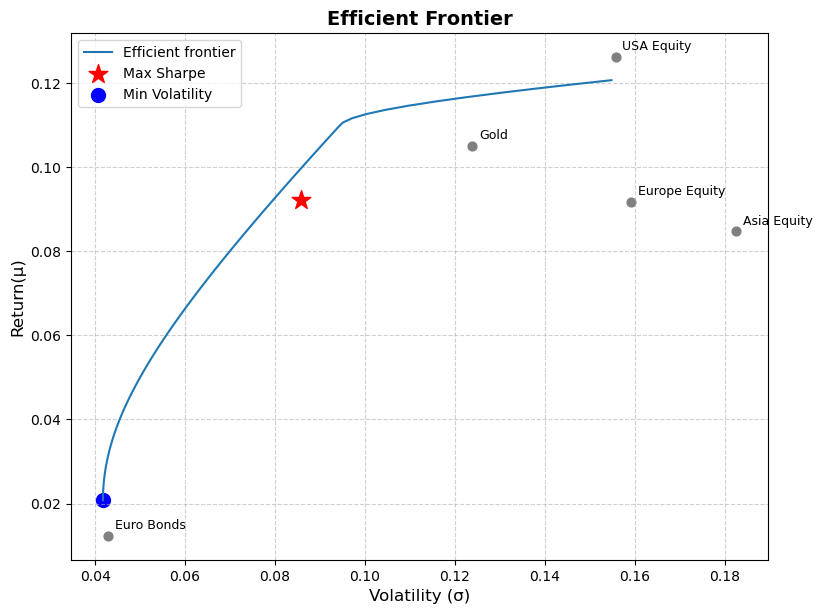

 Summary statistics for the best sharpe ratio portfolio



Return: 9.22% | Volatility: 8.58% | Sharpe Ratio: 1.07




In [3]:
# Creation of Efficient Frontier
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)

# each asset has 10% of minimum weight to make the simulation more realistic
ef = EfficientFrontier(mu, S, weight_bounds=(0.10, 1))

# Max Sharpe
w_sharpe = ef.max_sharpe()
return_sharpe, volatility_sharpe, sharpe_ratio = ef.portfolio_performance()

# Min Volatility
ef_min = EfficientFrontier(mu, S)
w_minvol = ef_min.min_volatility()
ret_minvol, vol_minvol, _ = ef_min.portfolio_performance()

# Calculation of the weight of the max sharpe ratio portfolio
cleaned_weights = ef.clean_weights()
weights_df = pd.DataFrame.from_dict(cleaned_weights, orient='index', columns=['Weight'])
weights_df = weights_df.sort_values(by='Weight', ascending=False)
print("\n Maximum Sharpe Ratio Portfolio")
print(weights_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# Lets Visualize the efficient frontier
fig, ax = plt.subplots(figsize=(8,6))
plotting.plot_efficient_frontier(EfficientFrontier(mu, S), ax=ax, show_assets=False)
ax.scatter(volatility_sharpe, return_sharpe, marker="*", color="red", s=200, label="Max Sharpe")
ax.scatter(vol_minvol, ret_minvol, marker="o", color="blue", s=100, label="Min Volatility")
returns = data.pct_change().dropna()
mean_returns = returns.mean() * 252
vols = returns.std() * (252 ** 0.5)
ax.scatter(vols, mean_returns, color="gray", s=40)
for i, txt in enumerate(data):
    ax.annotate(txt, (vols[i], mean_returns[i]), fontsize=9, xytext=(5,5), textcoords="offset points")

ax.set_title("Efficient Frontier", fontsize=14, fontweight="bold")
ax.set_xlabel("Volatility (σ)", fontsize=12)
ax.set_ylabel("Return(μ)", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()

plt.show()

# Performance summary
ret, vol, sharpe = ef.portfolio_performance(verbose=False)
print(" Summary statistics for the best sharpe ratio portfolio")
print("\n")
print(f"\nReturn: {ret:.2%} | Volatility: {vol:.2%} | Sharpe Ratio: {sharpe:.2f}")
print("\n")


 Please write your target return in %


 6


              Weight
Euro Bonds    42.88%
Gold          27.12%
Asia Equity   10.00%
Europe Equity 10.00%
USA Equity    10.00%
 
summary performance with the target return

Return: 6.00% | Volatility: 6.20% | Sharpe Ratio: 0.97


<Axes: xlabel='Ticker', ylabel='Ticker'>

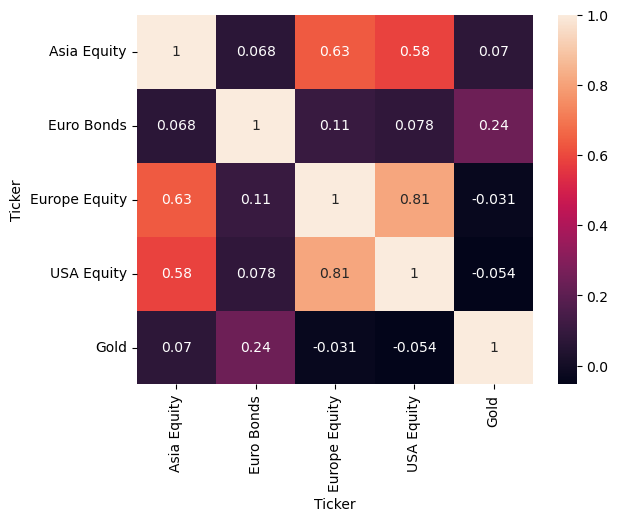

In [4]:
print(" Please write your target return in %")
target_return=float(input())/100
ef_return=EfficientFrontier (mu, S, weight_bounds = (0.1,100))
weight_target= ef_return.efficient_return(target_return)
weights_target = pd.DataFrame.from_dict(weight_target, orient='index', columns=['Weight'])
weights_target = weights_target.sort_values(by='Weight', ascending=False)
print(weights_target.to_string(formatters={'Weight': '{:.2%}'.format}))
ret1,vol1,sharpe1= ef_return.portfolio_performance()
print(" \nsummary performance with the target return")
print(f"\nReturn: {ret1:.2%} | Volatility: {vol1:.2%} | Sharpe Ratio: {sharpe1:.2f}")

daily_return=data.pct_change()
correlation=daily_return.corr()
sns.heatmap(correlation,annot=True)
